Dataset Shape:
(100, 9)

Missing Values:
Order_ID    0
Date        0
Product     0
Category    0
Sales       0
Profit      0
Region      0
Month       0
Year        0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Order_ID  100 non-null    object        
 1   Date      100 non-null    datetime64[ns]
 2   Product   100 non-null    object        
 3   Category  100 non-null    object        
 4   Sales     100 non-null    float64       
 5   Profit    100 non-null    float64       
 6   Region    100 non-null    object        
 7   Month     100 non-null    int32         
 8   Year      100 non-null    int32         
dtypes: datetime64[ns](1), float64(2), int32(2), object(4)
memory usage: 6.4+ KB
None

========= KPI Metrics =========
Total Sales: 250379.38
Total Profit: 45863.62
Average Sales: 2503.79
T

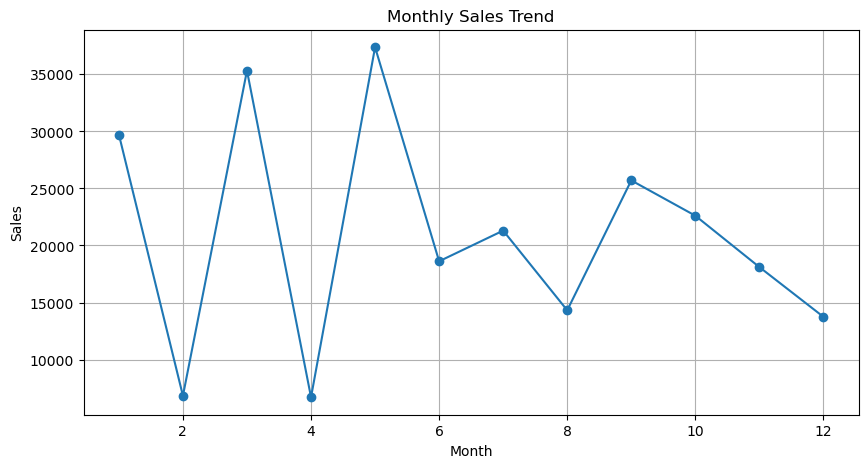

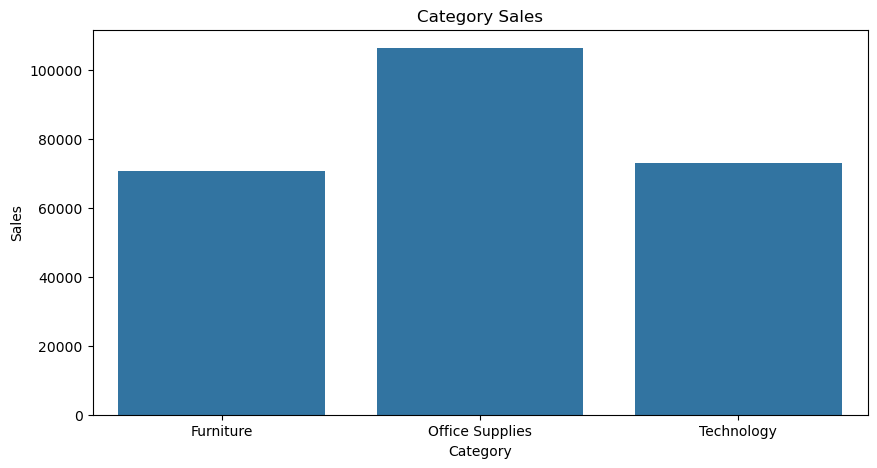

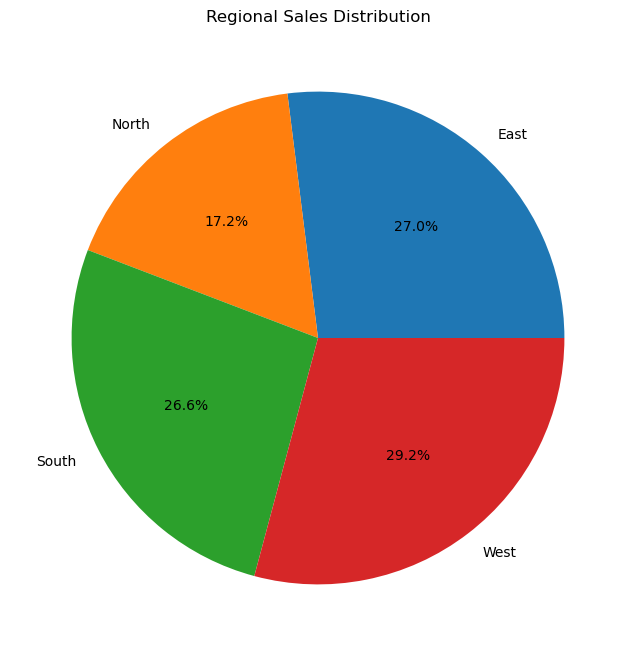

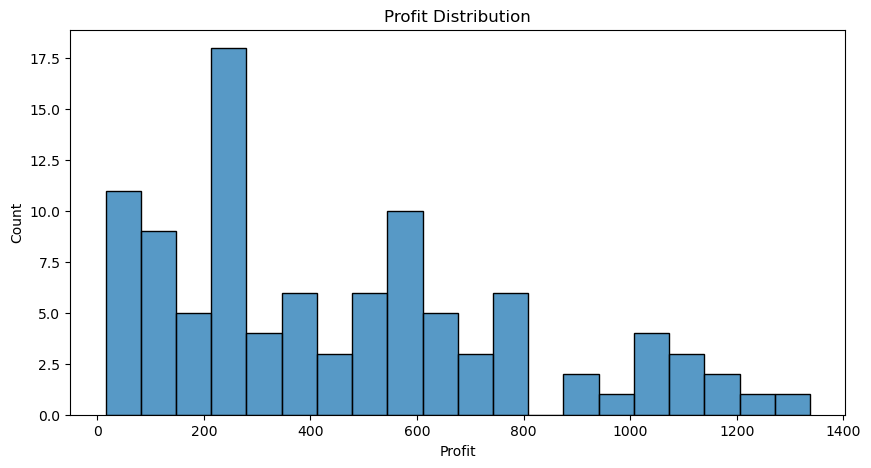

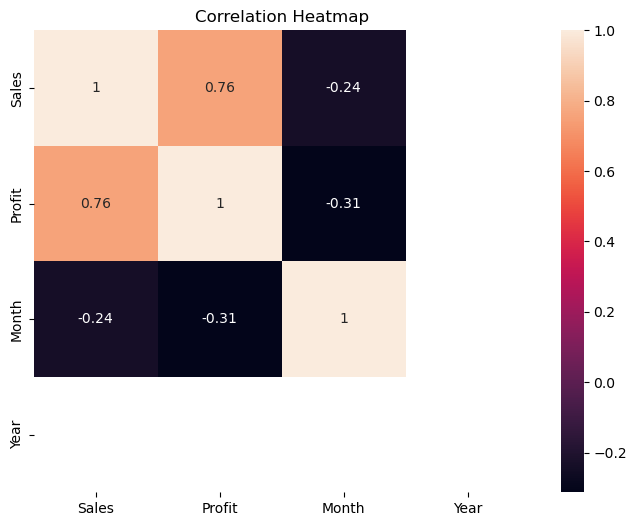


Top Selling Products
Product
Printer     45397.56
Laptop      42505.86
Keyboard    36212.51
Desk        35744.18
Monitor     35292.73
Mouse       30507.22
Chair       24719.32
Name: Sales, dtype: float64

========= Business Insights =========
Highest sales category: Office Supplies
Highest sales region: West
Project completed successfully


In [4]:
# ==============================
# Sales Trend Visualization Project
# ==============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("sales.csv")

# ==============================
# Data Cleaning
# ==============================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Convert Date column into datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Create Month and Year columns
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# ==============================
# Basic Information
# ==============================

print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

# ==============================
# KPI Metrics
# ==============================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
avg_sales = df["Sales"].mean()
total_orders = df["Order_ID"].nunique()

print("\n========= KPI Metrics =========")
print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))
print("Average Sales:", round(avg_sales,2))
print("Total Orders:", total_orders)

# ==============================
# Monthly Sales Trend
# ==============================

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()

plt.show()

# ==============================
# Category Sales Analysis
# ==============================

plt.figure(figsize=(10,5))

category_sales = df.groupby("Category")["Sales"].sum()

sns.barplot(
x=category_sales.index,
y=category_sales.values
)

plt.title("Category Sales")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

# ==============================
# Regional Sales Distribution
# ==============================

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,8))

plt.pie(
region_sales.values,
labels=region_sales.index,
autopct='%1.1f%%'
)

plt.title("Regional Sales Distribution")

plt.show()

# ==============================
# Profit Distribution
# ==============================

plt.figure(figsize=(10,5))

sns.histplot(
df["Profit"],
bins=20
)

plt.title("Profit Distribution")

plt.show()

# ==============================
# Correlation Heatmap
# ==============================

plt.figure(figsize=(8,6))

numeric_data = df.select_dtypes(include=np.number)

sns.heatmap(
numeric_data.corr(),
annot=True
)

plt.title("Correlation Heatmap")

plt.show()

# ==============================
# Top Selling Products
# ==============================

top_products = (
df.groupby("Product")["Sales"]
.sum()
.sort_values(ascending=False)
.head(10)
)

print("\nTop Selling Products")
print(top_products)

# ==============================
# Business Insights
# ==============================

highest_category = category_sales.idxmax()
highest_region = region_sales.idxmax()

print("\n========= Business Insights =========")

print(f"Highest sales category: {highest_category}")

print(f"Highest sales region: {highest_region}")

print("Project completed successfully")